In [12]:
# kết nội với drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# Làm sạch dữ liệu

In [3]:
np.set_printoptions(threshold=np.inf)
pd.set_option('display.max_rows', None)

In [4]:
np.set_printoptions(threshold=np.inf)
def unique_values(df, columns):
    for col in columns:
        if 'id' in col.lower() or df[col].isnull().sum() == 0:
            continue
        print(f"Unique values in '{col}': {df[col].unique()}")
    print("\n")

In [5]:
def cleaned_datetime(raw_datetime):
    raw_datetime = raw_datetime.str.replace(' UTC', '',regex=True)
    raw_datetime = raw_datetime.str.split('.').str[0]
    raw_datetime = pd.to_datetime(raw_datetime, errors='coerce')
    return raw_datetime

## Event table

In [6]:
events = pd.read_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/raw_data/events.csv')

In [7]:
events[(events['uri'].str.contains('purchase'))].nunique()

,0
id,181702
user_id,79980
sequence_number,4
session_id,181702
created_at,181526
ip_address,181701
city,7575
state,228
postal_code,15002
browser,5


In [8]:
# 1. Lấy tất cả các session_id duy nhất CÓ chứa 'cancel'
sessions_to_remove = events[(events['event_type'] == 'cancel')]['session_id'].unique()

# 2. Lọc bộ dữ liệu:
# Giữ lại tất cả các hàng mà 'session_id' KHÔNG (~) CÓ TRONG (isin) danh sách cần xóa
filtered_events = events[~events['session_id'].isin(sessions_to_remove)]

# 3. (Tùy chọn) Đếm số session_id duy nhất còn lại:
unique_sessions_count = filtered_events['session_id'].nunique()

print(f"Số session_id còn lại (đã lọc): {unique_sessions_count}")
# print(filtered_events) # Đây là DataFrame bạn muốn

Số session_id còn lại (đã lọc): 556657


In [9]:
filtered_events[filtered_events['event_type']=='purchase'].groupby('traffic_source').size()

,0
traffic_source,
Adwords,54695
Email,81849
Facebook,18184
Organic,9123
YouTube,17851


In [10]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2427758 entries, 0 to 2427757
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   user_id          float64
 2   sequence_number  int64  
 3   session_id       object 
 4   created_at       object 
 5   ip_address       object 
 6   city             object 
 7   state            object 
 8   postal_code      object 
 9   browser          object 
 10  traffic_source   object 
 11  uri              object 
 12  event_type       object 
dtypes: float64(1), int64(2), object(10)
memory usage: 240.8+ MB


In [11]:
events.isnull().sum()

,0
id,0
user_id,1124113
sequence_number,0
session_id,0
created_at,0
ip_address,0
city,23431
state,0
postal_code,0
browser,0


In [12]:
user_not_null = events[events['user_id'].notnull()]

In [13]:
user_not_null['event_type'].value_counts()

,count
event_type,
cart,344776
department,344776
product,344776
purchase,181702
home,87615


In [14]:
user_null = events[events['user_id'].isnull()]

In [15]:
user_null['event_type'].value_counts()

,count
event_type,
product,500000
department,249611
cart,249457
cancel,125045


cột ['city'] ngoài giá trị Null kỹ thuật còn có giá trị Null tự nhiên: city

In [16]:
df_cleaned_events = events.copy()
df_cleaned_events['city'] = df_cleaned_events['city'].fillna('Unknown')
df_cleaned_events['city'] = df_cleaned_events['city'].replace('City', 'Unknown')
df_cleaned_events['user_id'] = df_cleaned_events['user_id'].fillna(-1).astype(int)

In [17]:
df_cleaned_events['created_at'] = cleaned_datetime(df_cleaned_events['created_at'])

In [18]:
df_cleaned_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2427758 entries, 0 to 2427757
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   user_id          int64         
 2   sequence_number  int64         
 3   session_id       object        
 4   created_at       datetime64[ns]
 5   ip_address       object        
 6   city             object        
 7   state            object        
 8   postal_code      object        
 9   browser          object        
 10  traffic_source   object        
 11  uri              object        
 12  event_type       object        
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 240.8+ MB


In [19]:
df_cleaned_events.isnull().sum()

,0
id,0
user_id,0
sequence_number,0
session_id,0
created_at,0
ip_address,0
city,0
state,0
postal_code,0
browser,0


In [20]:
df_cleaned_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2427758 entries, 0 to 2427757
Data columns (total 13 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               int64         
 1   user_id          int64         
 2   sequence_number  int64         
 3   session_id       object        
 4   created_at       datetime64[ns]
 5   ip_address       object        
 6   city             object        
 7   state            object        
 8   postal_code      object        
 9   browser          object        
 10  traffic_source   object        
 11  uri              object        
 12  event_type       object        
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 240.8+ MB


In [21]:
# df_cleaned_events.to_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_events.csv', index=False)

## User table

In [ ]:
users = pd.read_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/raw_data/users.csv')
users.info()

/tmp/ipython-input-1010422982.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/raw_data/users.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              100000 non-null  int64  
 1   first_name      100000 non-null  object 
 2   last_name       100000 non-null  object 
 3   email           100000 non-null  object 
 4   age             100000 non-null  int64  
 5   gender          100000 non-null  object 
 6   state           100000 non-null  object 
 7   street_address  100000 non-null  object 
 8   postal_code     100000 non-null  object 
 9   city            99043 non-null   object 
 10  country         100000 non-null  object 
 11  latitude        100000 non-null  float64
 12  longitude       100000 non-null  float64
 13  traffic_source  100000 non-null  object 
 14  created_at      100000 non-null  object 
 15  user_geom       100000 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 12.2+ M

In [ ]:
users[users['id'] == -1]

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,user_geom


In [ ]:
users[users['city'] == 'City']

,id,first_name,last_name,email,age,gender,state,street_address,postal_code,city,country,latitude,longitude,traffic_source,created_at,user_geom
75927,57582,Melissa,Smith,melissasmith@example.com,59,F,Saitama,09832 Kathy Ridge,358-0026,City,Japan,35.824426,139.372654,Search,2020-05-06 18:55:00 UTC,POINT(139.3726538 35.82442568)
75928,60070,Douglas,Rodgers,douglasrodgers@example.net,28,M,Saitama,3327 Thomas Pines,358-0014,City,Japan,35.793749,139.379573,Search,2025-02-04 05:09:00 UTC,POINT(139.3795729 35.79374879)
75929,49962,Timothy,Miller,timothymiller@example.net,57,M,Saitama,34408 Chandler Radial,358-0014,City,Japan,35.793749,139.379573,Facebook,2021-03-07 18:18:00 UTC,POINT(139.3795729 35.79374879)


Vấn đề:
* Cột first_name và last_name cần được kết hợp tạo thành full_name
* Cột Age đang ở các giá trị rời rạc --> có thể gây vấn đề khi trực quan --> gom nhóm để dùng khi trực quan tiện hơn
* Cột created_at đang ở sai kiểu dữ liệu
* Cột user_geom hiện đang bị trùng lặp dữ liệu với 2 cột latitude và longitude --> có thể cân nhắc drop

In [ ]:
def age_group (age):
    if pd.isnull(age):
        return 'Unknown'
    elif age < 18:
        return 'Under 18'
    elif 18 <= age <= 22:
        return '18-22'
    elif 23 <= age <= 31:
        return '23-31'
    elif 32 <= age <= 60:
        return '32-60'
    else:
        return 'Above 60'

In [ ]:
df_cleaned_users = users.copy()

df_cleaned_users['city'] = df_cleaned_users['city'].replace('City', 'Unknown')
df_cleaned_users['city'] = df_cleaned_users['city'].fillna('Unknown')
df_cleaned_users['full_name'] = df_cleaned_users['first_name'] + ' ' + df_cleaned_users['last_name']
df_cleaned_users['age_group'] = df_cleaned_users['age'].apply(age_group)

df_cleaned_users = df_cleaned_users.drop(columns=['first_name', 'last_name','user_geom'])

In [ ]:
df_cleaned_users['created_at'] = cleaned_datetime(df_cleaned_users['created_at'])

In [ ]:
df_cleaned_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              100000 non-null  int64         
 1   email           100000 non-null  object        
 2   age             100000 non-null  int64         
 3   gender          100000 non-null  object        
 4   state           100000 non-null  object        
 5   street_address  100000 non-null  object        
 6   postal_code     100000 non-null  object        
 7   city            100000 non-null  object        
 8   country         100000 non-null  object        
 9   latitude        100000 non-null  float64       
 10  longitude       100000 non-null  float64       
 11  traffic_source  100000 non-null  object        
 12  created_at      100000 non-null  datetime64[ns]
 13  full_name       100000 non-null  object        
 14  age_group       100000 non-null  obje

In [ ]:
# df_cleaned_users.to_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_users.csv', index=False)

## Orders table

In [22]:
orders = pd.read_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/raw_data/orders.csv')
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125253 entries, 0 to 125252
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   order_id      125253 non-null  int64 
 1   user_id       125253 non-null  int64 
 2   status        125253 non-null  object
 3   gender        125253 non-null  object
 4   created_at    125253 non-null  object
 5   returned_at   12519 non-null   object
 6   shipped_at    81234 non-null   object
 7   delivered_at  43741 non-null   object
 8   num_of_item   125253 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 8.6+ MB


In [ ]:
orders.head(5)

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,69,50,Cancelled,F,2024-07-24 06:35:00 UTC,NaN,NaN,NaN,1
1,73,52,Cancelled,F,2023-07-16 16:27:00 UTC,NaN,NaN,NaN,1
2,80,56,Cancelled,F,2024-04-10 13:53:00 UTC,NaN,NaN,NaN,2
3,85,61,Cancelled,F,2022-11-26 03:07:00 UTC,NaN,NaN,NaN,2
4,89,64,Cancelled,F,2023-09-10 06:35:00 UTC,NaN,NaN,NaN,4


In [23]:
df_cleaned_orders = orders.copy()
df_cleaned_orders['created_at'] = cleaned_datetime(df_cleaned_orders['created_at'])
df_cleaned_orders['returned_at'] = cleaned_datetime(df_cleaned_orders['returned_at'])
df_cleaned_orders['shipped_at'] = cleaned_datetime(df_cleaned_orders['shipped_at'])
df_cleaned_orders['delivered_at'] = cleaned_datetime(df_cleaned_orders['delivered_at'])

In [ ]:
df_cleaned_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125253 entries, 0 to 125252
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      125253 non-null  int64         
 1   user_id       125253 non-null  int64         
 2   status        125253 non-null  object        
 3   gender        125253 non-null  object        
 4   created_at    125253 non-null  datetime64[ns]
 5   returned_at   12519 non-null   datetime64[ns]
 6   shipped_at    81234 non-null   datetime64[ns]
 7   delivered_at  43741 non-null   datetime64[ns]
 8   num_of_item   125253 non-null  int64         
dtypes: datetime64[ns](4), int64(3), object(2)
memory usage: 8.6+ MB


In [ ]:
# df_cleaned_orders.to_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_orders.csv', index=False)

## Order item table

In [ ]:
order_items = pd.read_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/raw_data/order_items.csv')
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181702 entries, 0 to 181701
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 181702 non-null  int64  
 1   order_id           181702 non-null  int64  
 2   user_id            181702 non-null  int64  
 3   product_id         181702 non-null  int64  
 4   inventory_item_id  181702 non-null  int64  
 5   status             181702 non-null  object 
 6   created_at         181702 non-null  object 
 7   shipped_at         118013 non-null  object 
 8   delivered_at       63607 non-null   object 
 9   returned_at        18205 non-null   object 
 10  sale_price         181702 non-null  float64
dtypes: float64(1), int64(5), object(5)
memory usage: 15.2+ MB


In [ ]:
order_items.head(10)

,id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,107371,74303,59366,14235,290237,Cancelled,2024-01-26 13:54:21 UTC,NaN,NaN,NaN,0.02
1,4244,2910,2267,14235,11467,Shipped,2023-10-25 10:58:01 UTC,2023-10-24 18:41:00 UTC,NaN,NaN,0.02
2,105506,73031,58345,14235,285189,Shipped,2023-07-27 22:53:12 UTC,2023-07-29 19:23:00 UTC,NaN,NaN,0.02
3,117694,81407,65113,14235,318160,Shipped,2025-01-13 10:29:42 UTC,2025-01-11 15:53:00 UTC,NaN,NaN,0.02
4,29028,20064,16101,14159,78444,Complete,2024-10-14 01:10:08 UTC,2024-10-15 19:00:00 UTC,2024-10-17 19:13:00 UTC,NaN,0.49
5,13474,9297,7455,14159,36458,Shipped,2024-03-10 13:19:12 UTC,2024-03-07 21:24:00 UTC,NaN,NaN,0.49
6,146342,101112,80820,14159,395488,Shipped,2024-12-10 15:17:02 UTC,2024-12-10 06:46:00 UTC,NaN,NaN,0.49
7,34468,23882,19182,28700,93149,Cancelled,2025-02-12 03:43:10 UTC,NaN,NaN,NaN,1.50
8,119576,82658,66064,28700,323212,Cancelled,2025-08-14 14:23:15 UTC,NaN,NaN,NaN,1.50
9,498,340,247,14202,1328,Complete,2024-09-20 08:36:49 UTC,2024-09-20 22:45:00 UTC,2024-09-22 11:51:00 UTC,NaN,1.50


Các cột về thông tin thời gian vận chuyển sẽ NULL hay không tùy thuộc vào status:
* Nếu status = shipped --> chỉ có shipped_at
* Nếu status = Cancelled/Processing --> các thuộc tính thời gian vận chuyển sẽ là null
* Nếu status = Return --> các thuộc tính vận chuyển được fill đủ

Vấn đề:
* Các cột thời gian đều đang không ở cùng dạng

In [ ]:
df_cleaned_order_items = order_items.copy()
df_cleaned_order_items['shipped_at'] = cleaned_datetime(df_cleaned_order_items['shipped_at'])
df_cleaned_order_items['delivered_at'] = cleaned_datetime(df_cleaned_order_items['delivered_at'])
df_cleaned_order_items['returned_at'] = cleaned_datetime(df_cleaned_order_items['returned_at'])
df_cleaned_order_items['created_at'] = cleaned_datetime(df_cleaned_order_items['created_at'])

In [ ]:
df_cleaned_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181702 entries, 0 to 181701
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 181702 non-null  int64         
 1   order_id           181702 non-null  int64         
 2   user_id            181702 non-null  int64         
 3   product_id         181702 non-null  int64         
 4   inventory_item_id  181702 non-null  int64         
 5   status             181702 non-null  object        
 6   created_at         181702 non-null  datetime64[ns]
 7   shipped_at         118013 non-null  datetime64[ns]
 8   delivered_at       63607 non-null   datetime64[ns]
 9   returned_at        18205 non-null   datetime64[ns]
 10  sale_price         181702 non-null  float64       
dtypes: datetime64[ns](4), float64(1), int64(5), object(1)
memory usage: 15.2+ MB


In [ ]:
# df_cleaned_order_items.to_csv(r'/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_order_items.csv', index=False)

# Đọc dữ liệu đã làm sạch

In [2]:
event_path = "/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_events.csv"

In [3]:
order_items_path = "/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_order_items.csv"

In [4]:
orders = "/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_orders.csv"

In [5]:
users = "/content/drive/MyDrive/DS111/Data/TheLookEcommerce/cleaned_data/cleaned_users.csv"

In [13]:
events = pd.read_csv(event_path)
order_items = pd.read_csv(order_items_path)
orders = pd.read_csv(orders)
users = pd.read_csv(users)

# Understand Tables

In [ ]:
import pandas as pd

def basic_infor_dataframe(df):
    # 1. In ra các thông tin tổng quan (Global Info)
    print(f"--- TỔNG QUAN BẢNG DỮ LIỆU ---")
    print(f"Kích thước (Dòng, Cột): {df.shape}")
    print(f"Số dòng bị trùng lặp (Duplicates): {df.duplicated().sum()}")
    print("-" * 30)

    # 2. Tạo bảng tóm tắt chi tiết cho từng cột
    summary_df = pd.DataFrame(index=df.columns)

    # Kiểu dữ liệu
    summary_df['Data Type'] = df.dtypes

    # Đếm số lượng Null
    summary_df['Null Count'] = df.isnull().sum()

    # Tỷ lệ % Null (giúp đánh giá chất lượng dữ liệu)
    summary_df['Null %'] = (df.isnull().sum() / len(df)) * 100

    # Số lượng giá trị duy nhất (giúp xác định cột nào là category, cột nào là ID)
    summary_df['Unique Values'] = df.nunique()

    # Lấy mẫu giá trị đầu tiên và thứ hai để dễ hình dung nội dung
    summary_df['First Value'] = df.iloc[0].values if len(df) > 0 else "N/A"
    summary_df['Second Value'] = df.iloc[1].values if len(df) > 1 else "N/A"

    # Trả về bảng tóm tắt để hiển thị đẹp mắt
    return summary_df


## 1\. Bảng `users` (Thông tin khách hàng)

Bảng này đóng vai trò là bảng **Dimension** (chiều) trung tâm về con người.

*   **Ý nghĩa:** Lưu trữ toàn bộ hồ sơ định danh và thông tin nhân khẩu học của những người đã đăng ký tài khoản trên hệ thống.
    
    
*   **Thuộc tính quan trọng:** `id` (khóa chính), `age_group` (nhóm tuổi), và `traffic_source` (nguồn dẫn khách đăng ký).
    

In [ ]:
info_table = basic_infor_dataframe(users)
display(info_table) # Nếu dùng Jupyter Notebook

--- TỔNG QUAN BẢNG DỮ LIỆU ---
Kích thước (Dòng, Cột): (100000, 16)
Số dòng bị trùng lặp (Duplicates): 0
------------------------------


,Data Type,Null Count,Null %,Unique Values,First Value,Second Value
id,int64,0,0.0,100000,62962,36671
email,object,0,0.0,83763,ashleycunningham@example.org,daltonfoster@example.com
age,int64,0,0.0,59,28,42
gender,object,0,0.0,2,F,M
state,object,0,0.0,230,Acre,Acre
street_address,object,0,0.0,100000,574 Jerome Track,4365 Evan Haven
postal_code,object,0,0.0,15645,69980-000,69980-000
city,object,0,0.0,7891,Unknown,Unknown
country,object,0,0.0,15,Brasil,Brasil
latitude,float64,0,0.0,16388,-8.065346,-8.065346


## 2\. Bảng `events` (Nhật ký hành vi)

Đây là bảng chứa dữ liệu **Log**, ghi lại "dấu chân" của người dùng.

*   **Ý nghĩa:** Ghi lại mọi tương tác của người dùng trên website hoặc ứng dụng, từ lúc họ vào trang chủ cho đến khi thoát ra hoặc thực hiện mua hàng.
    
*   **Thuộc tính quan trọng:** `event_type` (loại hành động: xem hàng, thêm vào giỏ, mua hàng), `session_id` (mã phiên truy cập).
    



In [ ]:
info_table = basic_infor_dataframe(events)
display(info_table) # Nếu dùng Jupyter Notebook

--- TỔNG QUAN BẢNG DỮ LIỆU ---
Kích thước (Dòng, Cột): (2427758, 14)
Số dòng bị trùng lặp (Duplicates): 0
------------------------------


,Data Type,Null Count,Null %,Unique Values,First Value,Second Value
id,int64,0,0.0,2427758,2183244,2039533
user_id,int64,0,0.0,79981,-1,-1
sequence_number,int64,0,0.0,13,3,3
session_id,object,0,0.0,681702,ab9d74d8-e4b0-44e6-90c2-22ddaea9293e,9e9ef447-805a-4f46-bf76-92b0828d4161
created_at,"datetime64[ns, UTC]",0,0.0,2200310,2019-03-22 14:29:00+00:00,2024-07-15 01:10:00+00:00
ip_address,object,0,0.0,681642,2.253.252.63,143.79.192.124
city,object,0,0.0,8777,São Paulo,São Paulo
state,object,0,0.0,231,São Paulo,São Paulo
postal_code,object,0,0.0,17319,02220-000,02675-031
browser,object,0,0.0,5,Chrome,Chrome


## 3\. Bảng `orders` (Tổng quan đơn hàng)

Bảng này quản lý thông tin giao dịch ở mức độ tổng quát (Header).

*   **Ý nghĩa:** Ghi nhận thông tin chung cho mỗi lần khách hàng thanh toán thành công, bao gồm trạng thái vận chuyển và tổng số lượng món hàng.


In [ ]:
info_table = basic_infor_dataframe(orders)
display(info_table) # Nếu dùng Jupyter Notebook

--- TỔNG QUAN BẢNG DỮ LIỆU ---
Kích thước (Dòng, Cột): (125253, 9)
Số dòng bị trùng lặp (Duplicates): 0
------------------------------


,Data Type,Null Count,Null %,Unique Values,First Value,Second Value
order_id,int64,0,0.000000,125253,69,73
user_id,int64,0,0.000000,79980,50,52
status,object,0,0.000000,5,Cancelled,Cancelled
gender,object,0,0.000000,2,F,F
created_at,object,0,0.000000,118983,2024-07-24 06:35:00,2023-07-16 16:27:00
returned_at,object,112734,90.005030,12470,NaN,NaN
shipped_at,object,44019,35.144068,79488,NaN,NaN
delivered_at,object,81512,65.077882,43214,NaN,NaN
num_of_item,int64,0,0.000000,4,1,1


## 4\. Bảng `order_items` (Chi tiết giao dịch)

Đây là bảng **Fact** (sự kiện) quan trọng nhất cho các báo cáo tài chính.

*   **Ý nghĩa:** Lưu trữ chi tiết từng sản phẩm cụ thể nằm trong mỗi đơn hàng. Một đơn hàng có thể có nhiều dòng trong bảng này.


In [ ]:
info_table = basic_infor_dataframe(order_items)
display(info_table)

--- TỔNG QUAN BẢNG DỮ LIỆU ---
Kích thước (Dòng, Cột): (181702, 11)
Số dòng bị trùng lặp (Duplicates): 0
------------------------------


,Data Type,Null Count,Null %,Unique Values,First Value,Second Value
id,int64,0,0.000000,181702,107371,4244
order_id,int64,0,0.000000,125253,74303,2910
user_id,int64,0,0.000000,79980,59366,2267
product_id,int64,0,0.000000,29041,14235,14235
inventory_item_id,int64,0,0.000000,181702,290237,11467
status,object,0,0.000000,5,Cancelled,Shipped
created_at,object,0,0.000000,181476,2024-01-26 13:54:21,2023-10-25 10:58:01
shipped_at,object,63689,35.051348,79488,NaN,2023-10-24 18:41:00
delivered_at,object,118095,64.993781,43214,NaN,NaN
returned_at,object,163497,89.980848,12470,NaN,NaN


# Visualization

## Customer Registration and Visit Oveview

### Tạo thêm cột năm cho user và events để phân tích theo năm

In [ ]:
# --- XỬ LÝ DỮ LIỆU ---
# 1. Chuyển đổi cột thời gian sang dạng datetime
users['created_at'] = pd.to_datetime(users['created_at'], format='mixed')
events['created_at'] = pd.to_datetime(events['created_at'], format='mixed')

# 2. Tạo cột 'year' để nhóm dữ liệu
users['year'] = users['created_at'].dt.year
events['year'] = events['created_at'].dt.year

In [ ]:
events.head()

,id,user_id,sequence_number,session_id,created_at,ip_address,city,state,postal_code,browser,traffic_source,uri,event_type,year
0,2183244,-1,3,ab9d74d8-e4b0-44e6-90c2-22ddaea9293e,2019-03-22 14:29:00+00:00,2.253.252.63,São Paulo,São Paulo,02220-000,Chrome,Email,/cancel,cancel,2019
1,2039533,-1,3,9e9ef447-805a-4f46-bf76-92b0828d4161,2024-07-15 01:10:00+00:00,143.79.192.124,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2024
2,1439363,-1,3,0a5deaeb-de11-45c4-83fd-165ad521ba22,2021-09-20 06:26:00+00:00,130.200.97.94,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2021
3,1469575,-1,3,f45477c6-bf9c-4403-b105-a394bcb7563f,2024-04-17 15:36:00+00:00,37.8.130.78,São Paulo,São Paulo,02675-031,Other,Email,/cancel,cancel,2024
4,1453745,-1,3,0dafd175-2e8f-4a8d-b637-03836a151996,2025-03-28 16:41:00+00:00,29.54.67.180,São Paulo,São Paulo,02675-031,Chrome,Email,/cancel,cancel,2025


In [ ]:
years_filter = range(2019, 2026)
years_filter, type(years_filter)

(range(2019, 2026), range)

### Biểu đồ đường mô tả sự thay đổi số lượng khách hàng và phiên hoạt động từ 2019 đến 2025

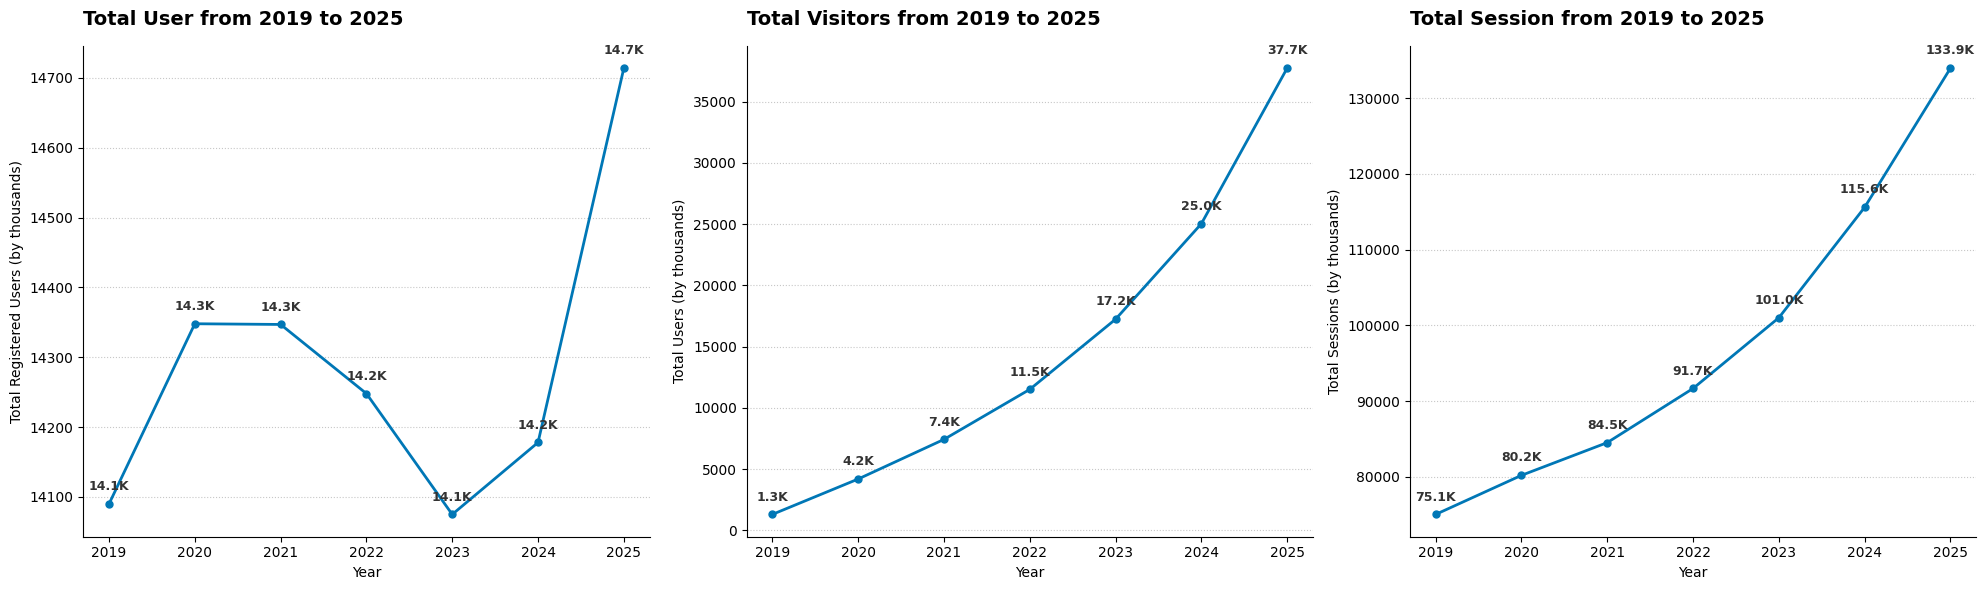

In [ ]:
# Lọc dữ liệu từ năm 2019 đến 2025
users_filtered = users[users['year'].isin(years_filter)]
events_filtered = events[events['year'].isin(years_filter)]

# 3. Tính toán số liệu cho 3 biểu đồ
# groupby('year')['col'].method()
data_users = users_filtered.groupby('year')['id'].count() # Đếm số lượng ID đăng ký theo năm
data_visitors = events_filtered.groupby('year')['user_id'].nunique() # Đếm số người dùng duy nhất
data_sessions = events_filtered.groupby('year')['session_id'].nunique() # Đếm số phiên làm việc

# --- BƯỚC 2: VẼ BIỂU ĐỒ  ---

# Thiết lập style
plt.style.use('default')

# Tạo khung hình chứa 3 biểu đồ con
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def plot_subplot(ax, data, title, ylabel):
    # Vẽ biểu đồ đường với màu xanh dương tiêu chuẩn
    ax.plot(data.index, data.values, color='#0077B6', marker='o', linewidth=2, markersize=5)

    # Thiết lập tiêu đề và nhãn với màu đen mặc định
    ax.set_title(title, loc='left', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    # Tinh chỉnh lưới và đường viền
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.7)

    # Hiển thị giá trị lên từng điểm dữ liệu
    for x, y in zip(data.index, data.values):
        label = f"{y/1000:.1f}K"
        ax.annotate(label,
                    (x, y),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center',
                    fontsize=9,
                    fontweight='bold',
                    color='#333333')

# --- THỰC THI VẼ ---

# Plot 1: Users
plot_subplot(axes[0], data_users,
             "Total User from 2019 to 2025",
             "Total Registered Users (by thousands)")

# Plot 2: Visitors
plot_subplot(axes[1], data_visitors,
             "Total Visitors from 2019 to 2025",
             "Total Users (by thousands)")

# Plot 3: Sessions
plot_subplot(axes[2], data_sessions,
             "Total Session from 2019 to 2025",
             "Total Sessions (by thousands)")

plt.tight_layout()
plt.show()

## Ordering overview

### Tạo thuộc tính năm cho bảng orders để phân tích chuyên sau vào các năm/

In [14]:
# --- BƯỚC 1: XỬ LÝ DỮ LIỆU ---
orders['created_at'] = pd.to_datetime(orders['created_at'], format='mixed')
orders['year'] = orders['created_at'].dt.year

### Biểu đồ đường mô tả sự thay đổi số lượng đơn hàng theo năm

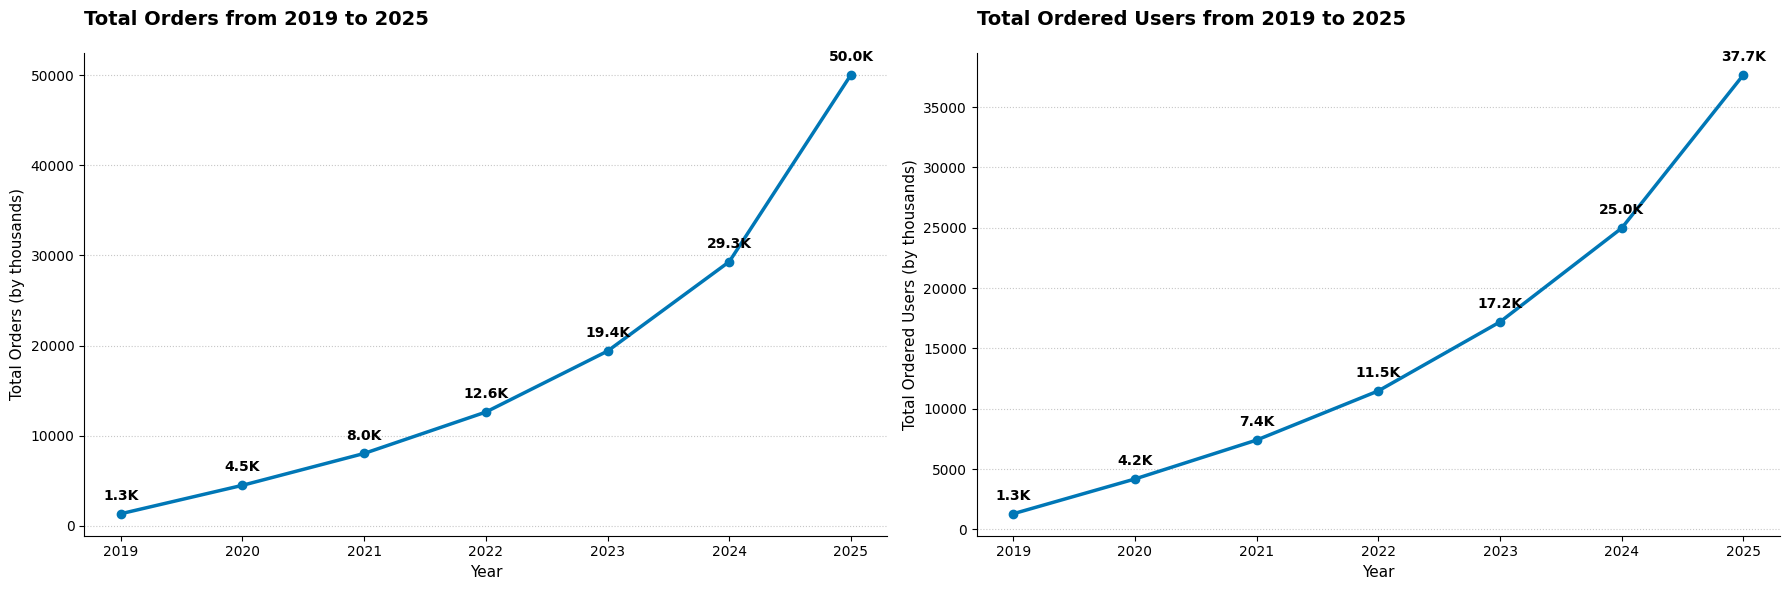

In [18]:
orders_yearly = orders[orders['year'].isin(range(2019, 2026))]

data_total_orders = orders_yearly.groupby('year')['order_id'].count() # Tổng đơn hàng theo năm
data_ordered_users = orders_yearly.groupby('year')['user_id'].nunique() # Tổng người mua theo năm

# --- BƯỚC 2: VẼ BIỂU ĐỒ (NỀN TRẮNG) ---
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

def plot_line_chart(ax, data, title, ylabel):
    # Vẽ đường màu xanh dương đậm
    ax.plot(data.index, data.values, color='#0077B6', marker='o', linewidth=2.5, markersize=6)

    ax.set_title(title, loc='left', fontsize=14, fontweight='bold', color='black', pad=20)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.7)

    # Annotate giá trị (K)
    for x, y in zip(data.index, data.values):
        label = f"{y/1000:.1f}K"
        ax.annotate(label, (x, y), textcoords="offset points", xytext=(0, 10),
                    ha='center', color='black', fontsize=10, fontweight='bold')

# Thực thi vẽ
plot_line_chart(axes[0], data_total_orders, "Total Orders from 2019 to 2025", "Total Orders (by thousands)")
plot_line_chart(axes[1], data_ordered_users, "Total Ordered Users from 2019 to 2025", "Total Ordered Users (by thousands)")

plt.tight_layout()
plt.show()

In [20]:
data_total_orders

,order_id
year,
2019,1349
2020,4504
2021,8038
2022,12628
2023,19390
2024,29306
2025,50038


### Biểu đồ đường mô tả sự thay đổi số lượng đơn hàng theo quý

In [15]:
# --- BƯỚC 1: XỬ LÝ DỮ LIỆU ---
orders['year'] = orders['created_at'].dt.year
orders['quarter'] = orders['created_at'].dt.quarter
orders_filtered = orders[orders['year'].isin(range(2019, 2026))].copy()

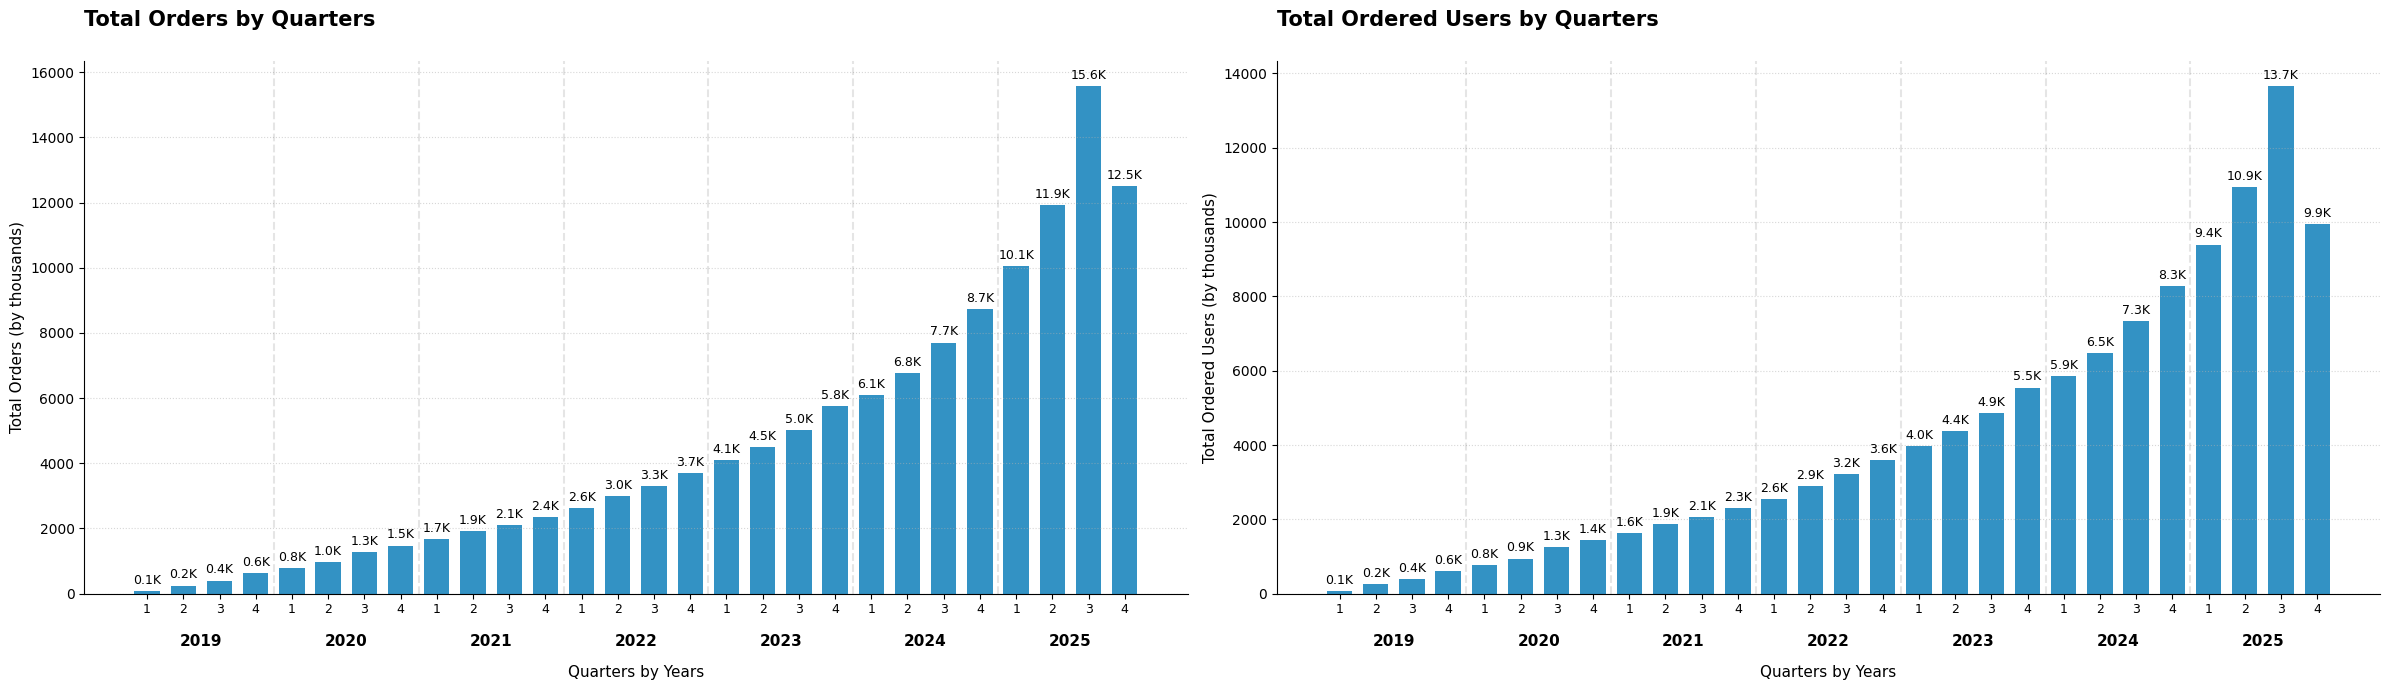

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
qt_orders = orders_filtered.groupby(['year', 'quarter'])['order_id'].count() # Đơn hàng theo quý
qt_users = orders_filtered.groupby(['year', 'quarter'])['user_id'].nunique() # Người mua theo quý

# --- BƯỚC 2: VẼ BIỂU ĐỒ (NỀN TRẮNG) ---
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(24, 7))

def plot_quarterly_bar(ax, data, title, ylabel):
    x_pos = np.arange(len(data))
    values = data.values

    # Vẽ cột màu xanh dương
    bars = ax.bar(x_pos, values, color='#0077B6', width=0.7, alpha=0.8)

    # Nhãn Quý (Hàng 1)
    quarters = [str(item[1]) for item in data.index]
    ax.set_xticks(x_pos)
    ax.set_xticklabels(quarters, fontsize=9, color='black')

    # Nhãn Năm (Hàng 2)
    years = [item[0] for item in data.index]
    unique_years = sorted(list(set(years)))
    for year in unique_years:
        indices = [i for i, x in enumerate(years) if x == year]
        if indices:
            center_index = sum(indices) / len(indices)
            ax.text(center_index, -max(values)*0.08, str(year),
                    ha='center', va='top', fontweight='bold', color='black', fontsize=11)
            if indices[-1] < len(data) - 1:
                ax.axvline(x=indices[-1] + 0.5, color='grey', linestyle='--', alpha=0.2)

    ax.set_title(title, loc='left', fontsize=15, fontweight='bold', pad=25)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlabel('Quarters by Years', fontsize=11, labelpad=35)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Annotate giá trị
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height/1000:.1f}K",
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, color='black')

# Thực thi vẽ
plot_quarterly_bar(axes[0], qt_orders, "Total Orders by Quarters", "Total Orders (by thousands)")
plot_quarterly_bar(axes[1], qt_users, "Total Ordered Users by Quarters", "Total Ordered Users (by thousands)")

plt.tight_layout()
plt.show()

In [29]:
# 1. VAR CartSession: Đếm số lượng session duy nhất có event_type là 'cart'
cart_sessions_count = events[events['event_type'] == 'cart']['session_id'].nunique()

# 2. VAR PurchaseSession: Đếm số lượng session duy nhất có event_type là 'purchase'
purchase_sessions_count = events[events['event_type'] == 'purchase']['session_id'].nunique()

# 3. RETURN: Tính toán tỷ lệ theo công thức
# Thêm kiểm tra điều kiện để tránh lỗi chia cho 0 (Divide by Zero)
if cart_sessions_count > 0:
    abandonment_rate = ((cart_sessions_count - purchase_sessions_count) / cart_sessions_count) * 100
else:
    abandonment_rate = 0.0

# In kết quả
print(f"Số session thêm vào giỏ: {cart_sessions_count}")
print(f"Số session đã mua hàng: {purchase_sessions_count}")
print(f"Tỷ lệ bỏ giỏ hàng (Abandonment Rate): {abandonment_rate:.2f}%")

Số session thêm vào giỏ: 431159
Số session đã mua hàng: 181702
Tỷ lệ bỏ giỏ hàng (Abandonment Rate): 57.86%


## User and Traffic Acquisition Analysis

### Biểu đồ tròn thống kê các nguồn khách hàng đăng kí từ

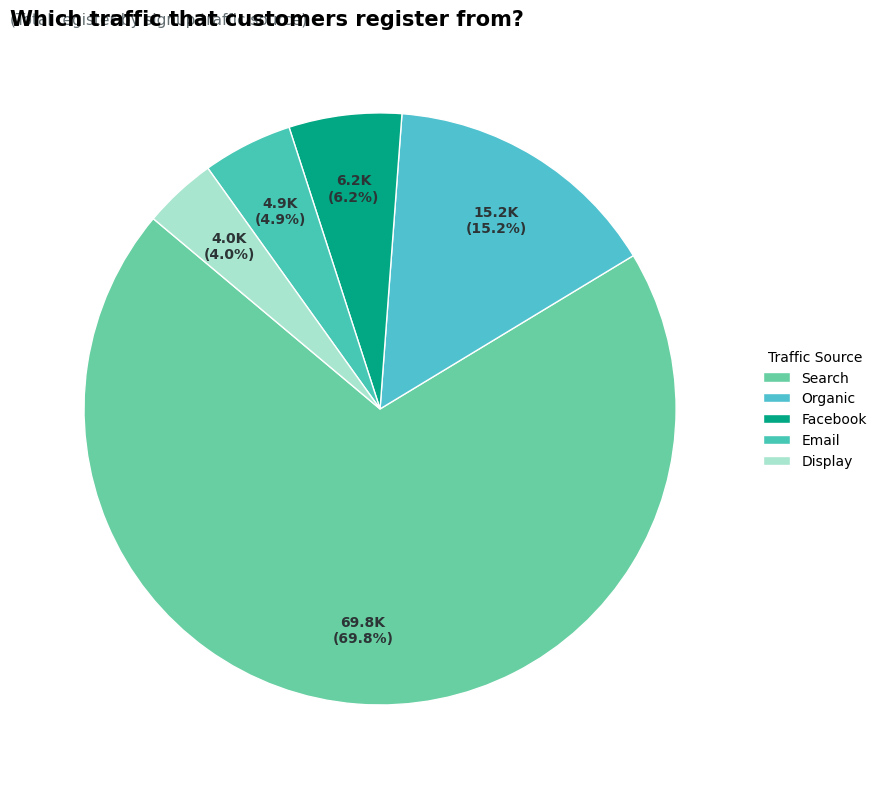

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Đếm số lượng user theo từng nguồn traffic
data_signup = users['traffic_source'].value_counts()

# --- 2. THIẾT LẬP GIAO DIỆN ---
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 8))

custom_colors = ['#67cfa2', '#50c1cf', '#02a783', '#47c8b5', '#a8e6cf', '#9cf3e9']

def plot_pie_chart(ax, data, title, subtitle):
    total = data.sum()

    def make_autopct(pct):
        absolute = int(round(pct/100.*total))
        if absolute >= 1_000_000:
            val_str = f'{absolute/1_000_000:.1f}M'
        elif absolute >= 1_000:
            val_str = f'{absolute/1_000:.1f}K'
        else:
            val_str = str(absolute)
        return f"{val_str}\n({pct:.1f}%)"

    wedges, texts, autotexts = ax.pie(
        data,
        autopct=make_autopct,
        startangle=140,
        colors=custom_colors[:len(data)],
        pctdistance=0.75,
        textprops={'color': "black", 'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )

    for text in autotexts:
        text.set_color('#2D3436')
        text.set_fontweight('bold')

    ax.set_title(title, loc='left', fontsize=15, fontweight='bold', color='black', pad=10)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color='#636E72', fontsize=11)

    ax.legend(wedges, data.index,
              title="Traffic Source",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1),
              frameon=False)

# --- 3. THỰC THI VẼ ---
plot_pie_chart(ax, data_signup,
               "Which traffic that customers register from?",
               "(Total register by signup traffic source)")

plt.tight_layout()
plt.show()

### Biểu đồ tròn thống kê nguồn với lượng phiên hoạt động

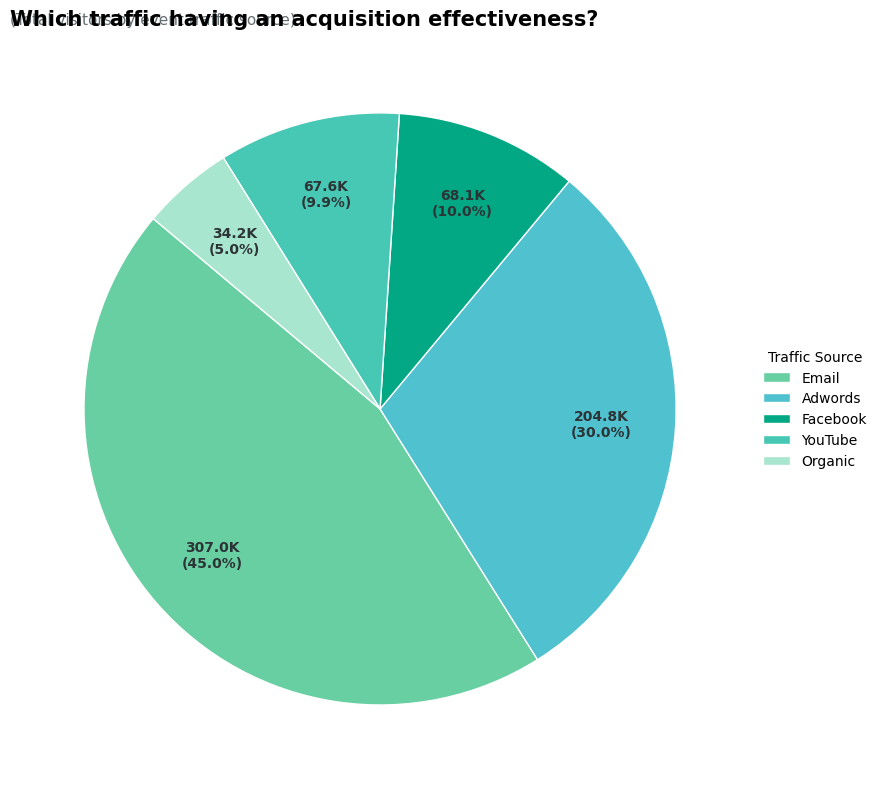

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Đếm số lượng session_id duy nhất từ mỗi nguồn traffic trong bảng events
data_traffic = events.groupby('traffic_source')['session_id'].nunique().sort_values(ascending=False)

# --- 2. THIẾT LẬP GIAO DIỆN ---
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 8)) # Tạo 1 hình đơn

custom_colors = ['#67cfa2', '#50c1cf', '#02a783', '#47c8b5', '#a8e6cf', '#9cf3e9']

def plot_pie_chart(ax, data, title, subtitle):
    total = data.sum()

    def make_autopct(pct):
        absolute = int(round(pct/100.*total))
        if absolute >= 1_000_000:
            val_str = f'{absolute/1_000_000:.1f}M'
        elif absolute >= 1_000:
            val_str = f'{absolute/1_000:.1f}K'
        else:
            val_str = str(absolute)
        return f"{val_str}\n({pct:.1f}%)"

    wedges, texts, autotexts = ax.pie(
        data,
        autopct=make_autopct,
        startangle=140,
        colors=custom_colors[:len(data)],
        pctdistance=0.75,
        textprops={'color': "black", 'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )

    for text in autotexts:
        text.set_color('#2D3436')
        text.set_fontweight('bold')

    ax.set_title(title, loc='left', fontsize=15, fontweight='bold', color='black', pad=10)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color='#636E72', fontsize=11)

    ax.legend(wedges, data.index,
              title="Traffic Source",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1),
              frameon=False)

# --- 3. THỰC THI VẼ ---
plot_pie_chart(ax, data_traffic,
               "Which traffic having an acquisition effectiveness?",
               "(Total visitors by event traffic source)")

plt.tight_layout()
plt.show()

### Biểu đồ tròn thống kế doanh thu theo từng nguồn

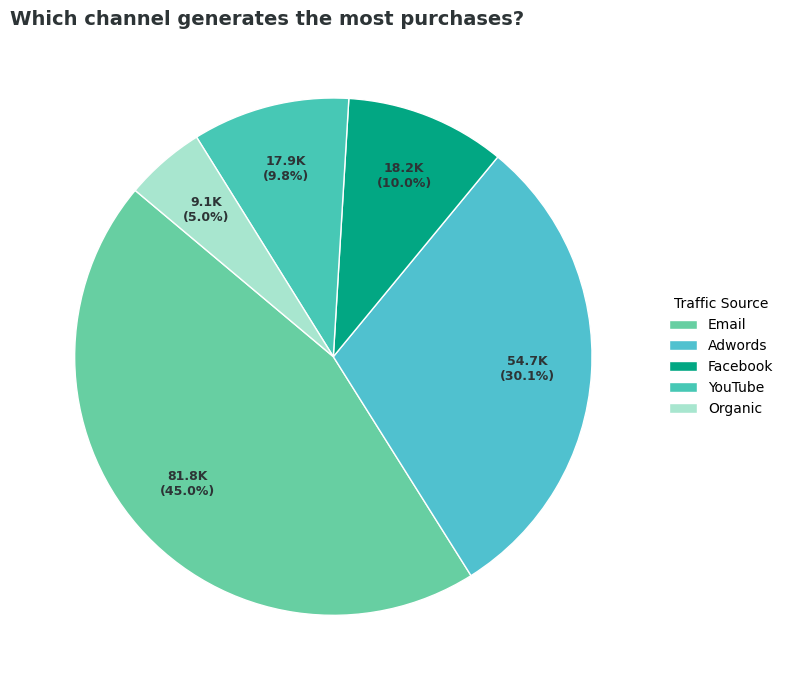

In [ ]:
# --- CẤU HÌNH CHUNG ---
plt.style.use('default') # Chuyển sang nền trắng
custom_colors = ['#67cfa2', '#50c1cf', '#02a783', '#47c8b5', '#a8e6cf', '#9cf3e9']
text_color = '#2d3436'

# 1. BIỂU ĐỒ TRÒN: Which channel generates the most purchases?
def plot_purchase_pie(events):
    # Xử lý dữ liệu
    events['created_at'] = pd.to_datetime(events['created_at'], format='mixed')
    events['year'] = events['created_at'].dt.year
    purchase_events = events[(events['event_type'] == 'purchase') & (events['year'].isin(range(2019, 2026)))]
    data = purchase_events['traffic_source'].value_counts()

    fig, ax = plt.subplots(figsize=(10, 7))

    def make_autopct(pct):
        total = data.sum()
        absolute = int(round(pct/100.*total))
        val_str = f'{absolute/1000:.1f}K' if absolute >= 1000 else str(absolute)
        return f"{val_str}\n({pct:.1f}%)"

    wedges, texts, autotexts = ax.pie(
        data, autopct=make_autopct, startangle=140,
        colors=custom_colors, pctdistance=0.75,
        textprops={'color': text_color, 'fontsize': 9},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )

    for text in autotexts:
        text.set_fontweight('bold')

    ax.set_title("Which channel generates the most purchases?", loc='left', fontsize=14, fontweight='bold', color=text_color)
    ax.legend(wedges, data.index, title="Traffic Source", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), frameon=False)
    plt.tight_layout()
    plt.show()
plot_purchase_pie(events)

### Biể u đồ cột ghép so sánh hiệu suất các nguồn

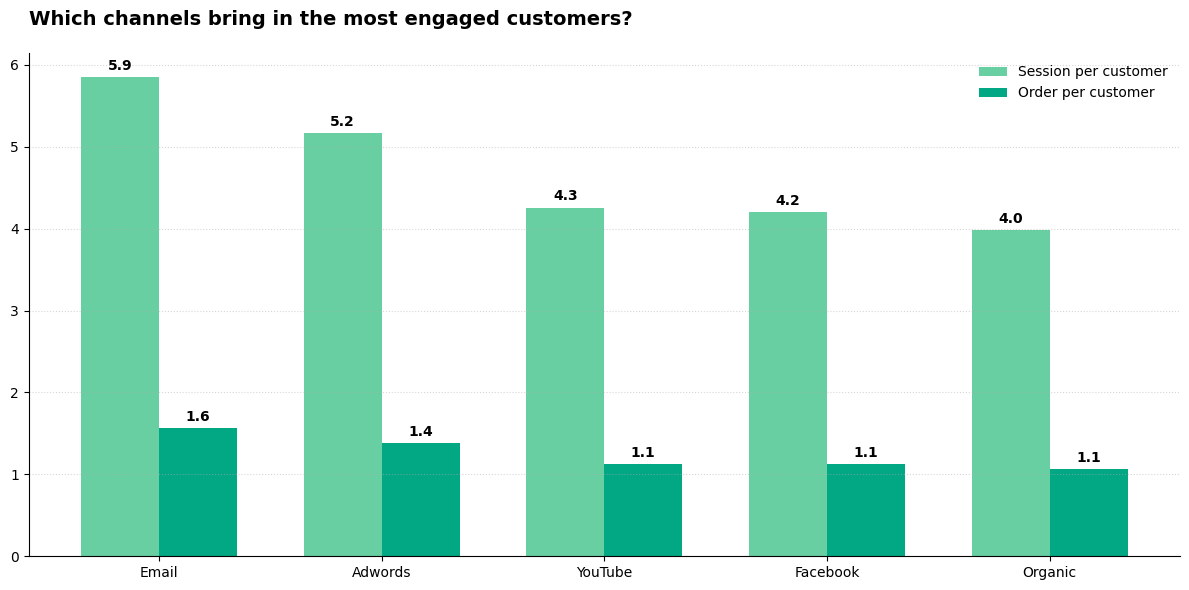

In [ ]:
# 2. BIỂU ĐỒ CỘT GHÉP: Which channels bring in the most engaged customers?
def plot_engagement_bar(events):
    # Xử lý dữ liệu
    df_filtered = events[events['year'].isin(range(2019, 2026))].copy()
    stats = df_filtered.groupby('traffic_source').agg(
        total_visitors=('user_id', 'nunique'),
        total_sessions=('session_id', 'nunique'),
        total_orders=('event_type', lambda x: (x == 'purchase').sum())
    )
    stats['session_per_customer'] = stats['total_sessions'] / stats['total_visitors']
    stats['order_per_customer'] = stats['total_orders'] / stats['total_visitors']

    target_sources = ['Email', 'Adwords', 'YouTube', 'Facebook', 'Organic']
    plot_data = stats.loc[target_sources].sort_values('session_per_customer', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(plot_data))
    width = 0.35

    # Sử dụng 2 màu tương phản trong bảng màu custom
    rects1 = ax.bar(x - width/2, plot_data['session_per_customer'], width, label='Session per customer', color='#67cfa2')
    rects2 = ax.bar(x + width/2, plot_data['order_per_customer'], width, label='Order per customer', color='#02a783')

    ax.set_title("Which channels bring in the most engaged customers?", loc='left', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data.index)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    ax.legend(frameon=False)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)
    plt.tight_layout()
    plt.show()
# --- THỰC THI ---
plot_engagement_bar(events)

### Biểu đồ thanh ngang chồng so sánh tỉ lệ hành vi của từng nguồn

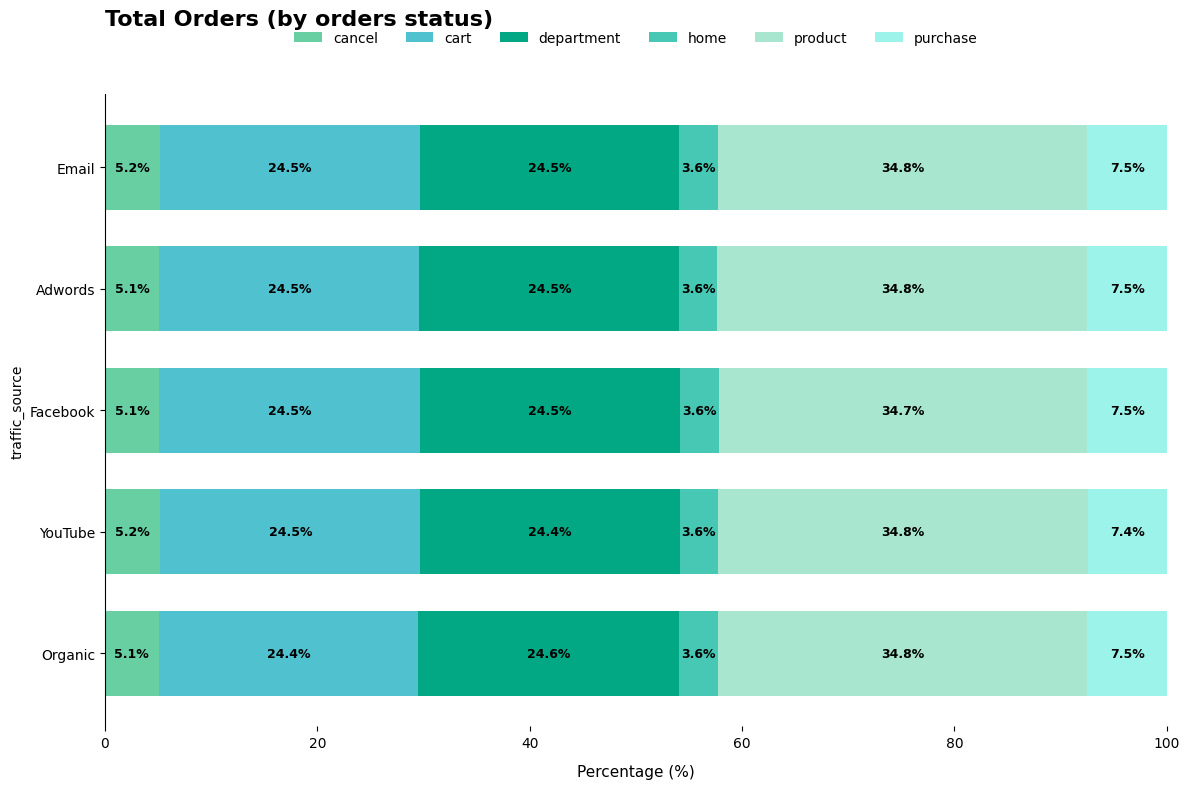

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- CẤU HÌNH CHUNG ---
plt.style.use('default')
custom_colors = ['#67cfa2', '#50c1cf', '#02a783', '#47c8b5', '#a8e6cf', '#9cf3e9']
text_color = '#2d3436'

def plot_status_stacked_bar(events):
    # Xử lý dữ liệu
    df_filtered = events[events['year'].isin(range(2019, 2026))].copy()
    pivot_df = pd.crosstab(df_filtered['traffic_source'], df_filtered['event_type'], normalize='index') * 100

    event_order = ['cancel', 'cart', 'department', 'home', 'product', 'purchase']
    existing_events = [e for e in event_order if e in pivot_df.columns]
    target_sources = ['Email', 'Adwords', 'Facebook', 'YouTube', 'Organic']
    plot_data = pivot_df.loc[target_sources, existing_events].iloc[::-1]

    # Tăng chiều cao figsize để có không gian cho tiêu đề và chú thích
    fig, ax = plt.subplots(figsize=(12, 8))
    plot_data.plot(kind='barh', stacked=True, ax=ax, color=custom_colors, width=0.7)

    # Tăng pad lên 50 để đẩy tiêu đề lên cao hẳn khỏi phần chú thích
    ax.set_title("Total Orders (by orders status)", loc='left', fontsize=16, fontweight='bold', pad=50)

    ax.set_xlim(0, 100)
    ax.set_xlabel('Percentage (%)', fontsize=11, labelpad=10)

    # Điều chỉnh bbox_to_anchor lên 1.12 để nằm giữa tiêu đề và biểu đồ
    ax.legend(loc='upper center',
              bbox_to_anchor=(0.5, 1.12),
              ncol=len(existing_events),
              frameon=False,
              fontsize=10)

    # Bỏ viền thừa
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Hiển thị số liệu phần trăm
    for p in ax.patches:
        width = p.get_width()
        if width > 3:
            ax.annotate(f'{width:.1f}%',
                        (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                        ha='center', va='center',
                        color='black', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Thực thi
plot_status_stacked_bar(events)

## User behaviors in purchasing funnel

### Biểu đồ tròn về tỉ lệ % hành vi khách hàng

In [ ]:
activity_count = events.groupby('event_type')['session_id'].nunique().sort_values(ascending=False)
print(activity_count)

event_type
product       681702
department    431313
cart          431159
purchase      181702
cancel        125045
home           87615
Name: session_id, dtype: int64


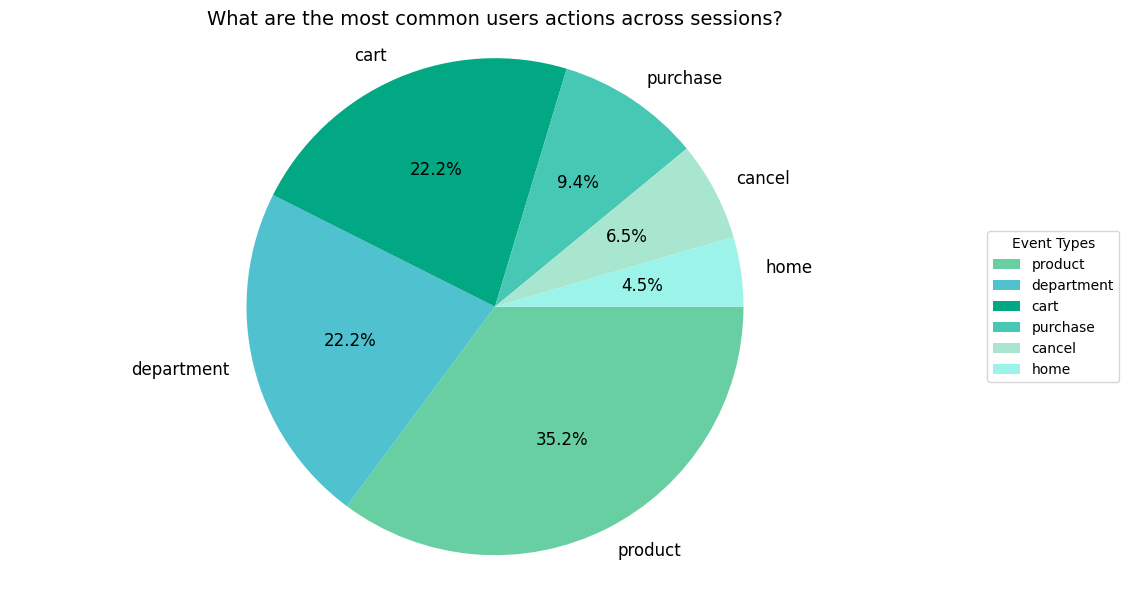

In [ ]:
plt.figure(figsize=(10,6))
wedges, texts, autotexts = plt.pie(activity_count, labels = activity_count.index, autopct='%1.1f%%',
                                   counterclock=False, colors=custom_colors, textprops={'fontsize': 12})
plt.title('What are the most common users actions across sessions?', fontsize=14)
plt.axis('equal')

plt.tight_layout()
plt.legend(wedges, activity_count.index, title="Event Types", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

### Biểu đồ cột hiển thị mức độ tương tác trung bình cho từng loại sự kiện.

*   `events.groupby('event_type')['session_id'].agg(['count', 'nunique'])`: Gom nhóm theo loại sự kiện và tính hai chỉ số:
    
    *   `count`: Tổng số lần sự kiện đó xảy ra.
        
    *   `nunique`: Số lượng phiên truy cập duy nhất có chứa sự kiện đó.
        
*   `average_interact = summary['count'] / summary['nunique']`: Đây là chỉ số quan trọng nhất. Nó tính **tỷ lệ lặp lại**. Nếu con số này bằng 1.0, nghĩa là mỗi session khách chỉ làm việc đó 1 lần. Nếu > 1.0, khách đang lặp lại hành động đó nhiều lần trong một phiên.

In [ ]:
summary = events.groupby('event_type')['session_id'].agg(['count', 'nunique'])
average_interact = summary['count']/summary['nunique']
print(summary)
print(average_interact)

             count  nunique
event_type                 
cancel      125045   125045
cart        594233   431159
department  594387   431313
home         87615    87615
product     844776   681702
purchase    181702   181702
event_type
cancel        1.000000
cart          1.378222
department    1.378087
home          1.000000
product       1.239216
purchase      1.000000
dtype: float64


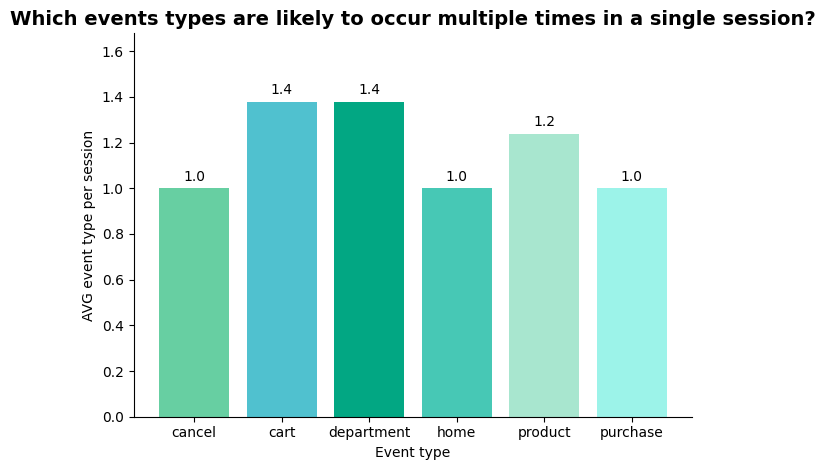

In [ ]:
bars = plt.bar(average_interact.index, average_interact.values, color=custom_colors)

for bar in bars:
    y_val = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_val + 0.02,
        round(y_val, 1),
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
    )

plt.title('Which events types are likely to occur multiple times in a single session?', fontsize=14, fontweight='bold')
plt.ylabel('AVG event type per session')
plt.xlabel('Event type')

plt.ylim(0, average_interact.max() + 0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

* Hành vi xem chi tiết sản phẩm 'product' đang là hành vi phổ biến nhất tại THELOOK, theo sau đó là department và cart ==> Khách hàng tập trung nhiều vào việc xem chi tiết, đánh giá sản phẩm và lưu trữ vào giỏ hàng.
* Tỉ lệ thao tác mua chỉ có 9.4% ==> Tỉ lệ chuyển đổi từ đánh giá sản phẩm (khía cạnh khách hàng) sang việc tạo doanh thu cho doanh nghiệp thấp.
* Mỗi khách hàng có hành vi tìm hiểu sản phẩm > 1 lần.

**Main insight:** Đây là hành vi phổ biến và phản ánh đúng hành vi khách hàng thường có trên các nền tảng E-Commerce.

### Biểu đồ cột thống kê phiên nào được thực hiện đầu tiên

In [ ]:
first_sequence = events[events['sequence_number'] == 1]
first_action = first_sequence['event_type'].value_counts()
print(first_action)

event_type
department    343698
product       250389
home           87615
Name: count, dtype: int64


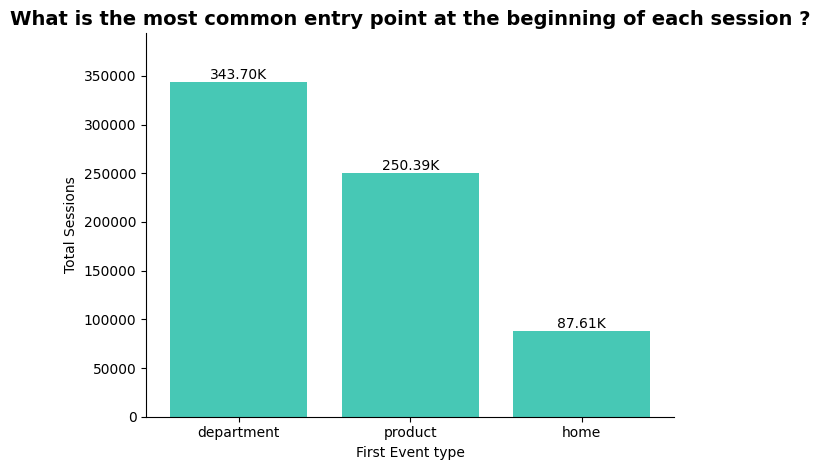

In [ ]:
first_action_bars = plt.bar(first_action.index, first_action.values, color='#47c8b5')

for bar in first_action_bars:
    y_val = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_val + 50,
        f'{y_val/1000:.2f}K',
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
    )

plt.title('What is the most common entry point at the beginning of each session ?', fontsize=14, fontweight='bold')
plt.ylabel('Total Sessions')
plt.xlabel('First Event type')

plt.ylim(0, max(first_action.values) + 50000)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Khi tương tác với THELOOK khách hàng hầu như đã xác định được ngành hàng/sản phẩm mình muốn xem/mua chứ không phải họ vào trang chủ và thực hiện việc lướt dạo.

### Biểu đồ cột thống kê phiên nào được thực hiện cuối

In [ ]:
sequence_sort = events.sort_values(by = ['session_id', 'sequence_number'], ascending=[True, False])
last_sequence = sequence_sort.drop_duplicates(subset=['session_id'], keep='first')
last_action = last_sequence['event_type'].value_counts()
print(last_action)

event_type
product     250543
purchase    181702
cancel      125045
cart        124412
Name: count, dtype: int64


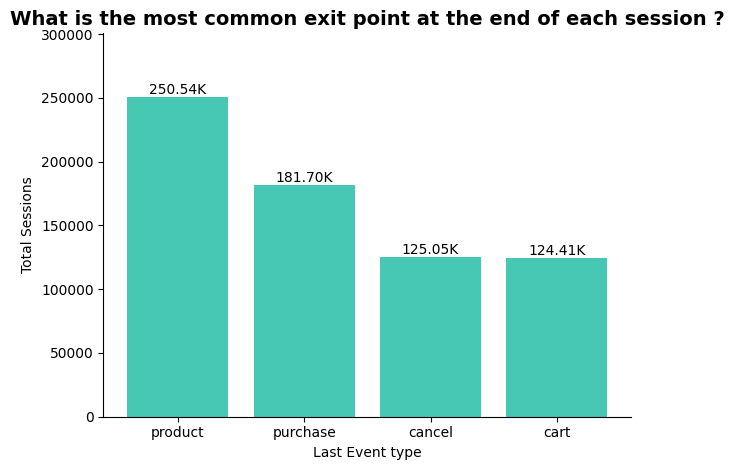

In [ ]:
last_action_bars = plt.bar(last_action.index, last_action.values, color='#47c8b5')

for bar in last_action_bars:
    y_val = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_val + 50,
        f'{y_val/1000:.2f}K',
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
    )

plt.title('What is the most common exit point at the end of each session ?', fontsize=14, fontweight='bold')
plt.ylabel('Total Sessions')
plt.xlabel('Last Event type')
plt.ylim(0, max(last_action.values) + 50000)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

* Mặc dù từ biểu đồ trên có thể thấy khách hàng trung bình chỉ thực hiện phiên mua sắm 1 lần nhưng khi thống kê lượt hành động cuối cùng thì purchase cũng nằm trong top 2 hành vi được thực hiện nhiều nhất.
* Tuy nhiên điểm đáng chú ý là khách hàng đang chỉ dừng lại ở việc xem sản phẩm (bước cuối) quá nhiều. Một mô hình kinh doanh lý tưởng nên có lượt kết thúc phiên là Purchase và Cart càng cao càng tốt.

### BIểu đồ cột ngang thống kế người dùng theo vị trí địa lý

In [ ]:
df_merge = pd.merge(orders, users[['id', 'country', 'city']], left_on='user_id', right_on='id', how='left')

In [ ]:
top_countries = df_merge.groupby('country')['order_id'].nunique().sort_values(ascending=False)

In [ ]:
top_cities = df_merge.groupby('city')['order_id'].nunique().sort_values(ascending=False)
top_cities = top_cities[~top_cities.index.isin(['', 'Unknown'])].head(20)

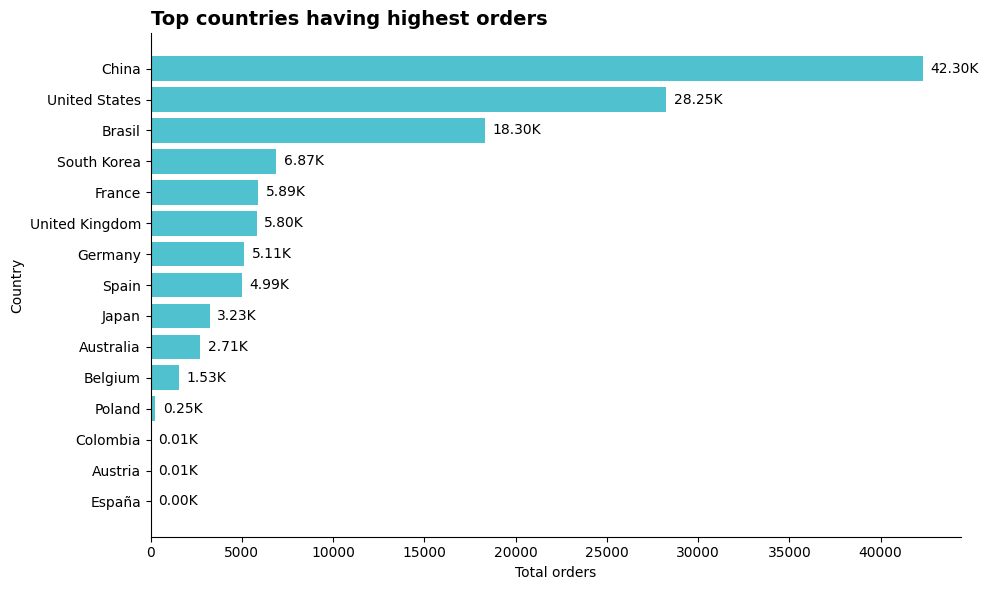

In [ ]:
plt.figure(figsize=(10, 6))

top_countries_barh = plt.barh(top_countries.index, top_countries.values, color='#50c1cf')

plt.gca().invert_yaxis()  # Đảo ngược trục y để quốc gia có số đơn hàng cao nhất ở trên cùng

for barh in top_countries_barh:
    width = barh.get_width()
    plt.text(
        width + (top_countries.max() * 0.01),
        barh.get_y() + barh.get_height() / 2,
        f'{width/1000:.2f}K',
        va = 'center',
        color = 'black',
        fontsize = 10,
    )

plt.title('Top countries having highest orders', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Total orders')
plt.ylabel('Country')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

* Trung Quốc, US, Brazil đang thống lĩnh thị trường với lượng đơn hàng đều trên 15k.
* Có thể thấy sự phân bố lệch về thị trường kinh doanh: kể cả trong top 3 quốc gia có doanh thu cao
    * Xét trong top 3 có lượng đơn nhiều thì Trung Quốc cũng đã gap so với US > 14k đơn, còn US thì hơn Brazil 10k đơn
    * Xét các quốc gia trong top so với phần còn lại thì khoảng cách càng cách xa hơn khi Brzail (3rd) đã gap Korea ~2.7 lượng đơn.  
* ==> Thị trường của THELOOK đang tập trung mạnh tại một số quốc gia nhất định, điều này tồn tại tương đối những rủi ro về sự ổn định, bởi nếu các quốc gia chủ chốt có vấn đề về tài chính hoặc thay đổi chính sách sẽ ảnh hưởng rất nặng đến doanh thu của THELOOK.

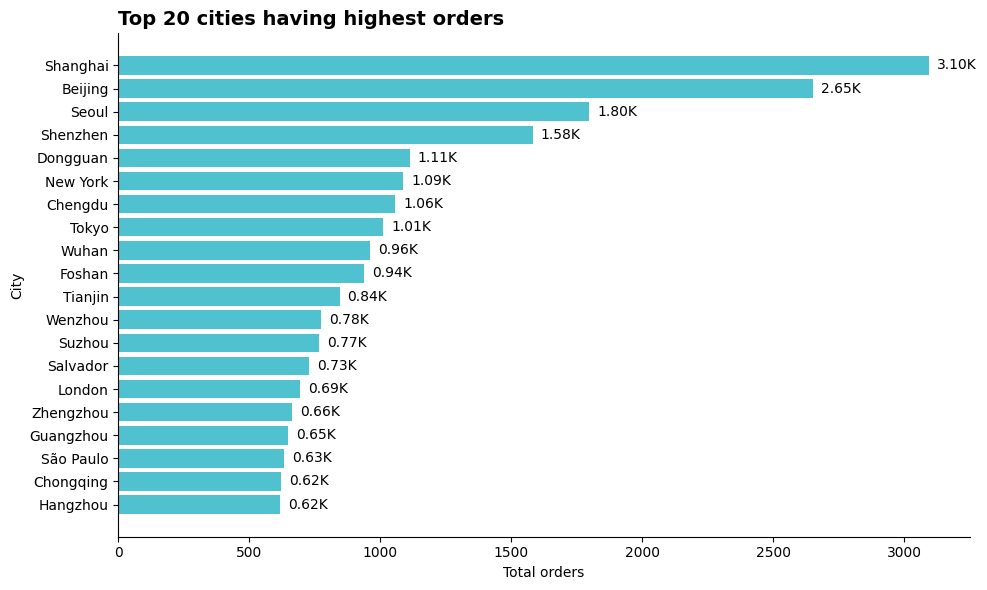

In [ ]:
plt.figure(figsize=(10, 6))

top_cities_barh = plt.barh(top_cities.index, top_cities.values, color='#50c1cf')

plt.gca().invert_yaxis()  # Đảo ngược trục y để quốc gia có số đơn hàng cao nhất ở trên cùng

for barh in top_cities_barh:
    width = barh.get_width()
    plt.text(
        width + (top_cities.max() * 0.01),
        barh.get_y() + barh.get_height() / 2,
        f'{width/1000:.2f}K',
        va = 'center',
        color = 'black',
        fontsize = 10,
    )

plt.title('Top 20 cities having highest orders', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Total orders')
plt.ylabel('City')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Khi xét chi tiết hơn về các thành phố có lượng đơn cao nhất có thể thấy THELOOK được sử rộng rãi ở mọi tỉnh thành của của Trung Quốc, trong khi các quốc gia còn lại chỉ tập trung ở 1 số vùng nhất định (ví dụ: Korea (Seoul), Japan (Tokyo), ...)

### Plot biểu đồ cột theo nhóm tuổi

In [ ]:
items_users = pd.merge(order_items, users[['id','age_group']], left_on='user_id', right_on='id', how='inner')

In [ ]:
age_spending = items_users.groupby('age_group')['sale_price'].sum().sort_values(ascending=False)
age_spending

,sale_price
age_group,
32-60,5.286092e+06
Above 60,1.843023e+06
23-31,1.667965e+06
Under 18,1.109342e+06
18-22,8.987755e+05


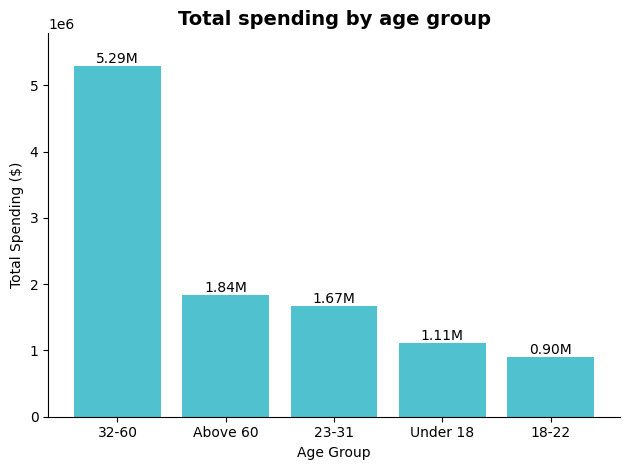

In [ ]:
age_spending_bars = plt.bar(age_spending.index, age_spending.values, color='#50c1cf')

for bar in age_spending_bars:
    y_val = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_val + 50,
        f'{y_val/1000000:.2f}M',
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
    )

plt.title('Total spending by age group', fontsize=14, fontweight='bold')
plt.ylabel('Total Spending ($)')
plt.xlabel('Age Group')
plt.ylim(0, age_spending.max() + 500000)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

* **Khi phân nhóm user theo độ tuổi thì nhóm kì vọng:**
    * Under 18: học sinh chưa đến độ tuổi lao động ==> thu nhập hạn chế nhất
    * 18-22: Sinh viên, có khả năng tham gia thị trường lao động nhưng còn hạn chế về thu nhập
    * 23-31: Độ tuổi xây dựng sự nghiệp ==> thu nhập chưa ổn định nhưng phần nào cũng có thể tự kiếm thu nhập theo tháng
    * 23-60: Độ tuổi có thu nhập ổn định nhất
    * Above 60: Thu nhập đến từ chế độ hưu trí   
Từ Total Spending bên trên đã đạt đúng kì vọng phân chia nhóm tuổi: Nhóm 32-60 đang tạo ra doanh thu nhiều nhất cho doanh nghiệp, sau đó là 60+, 23-31. Đứng cuối cùng là nhóm học sinh, sinh viên.

**Tuy nhiên tổng số doanh thu sẽ khá dễ bị ảnh hưởng bởi số lượng khách hàng --> để xem liệu sự chênh lệch giữa các nhóm có thật sự đến từ nội tại (AOv) của nhóm không thì cần làm kiểm định.**

### Kiểm định

#### Kiểm định mức chi tiêu giữa các nhóm tuổi

In [ ]:
# Merge order_items with users on user_id
items_users.drop(columns=['id_y'], inplace=True)
items_users.head()

,id_x,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price,age_group
0,107371,74303,59366,14235,290237,Cancelled,2024-01-26 13:54:21,NaN,NaN,NaN,0.02,Above 60
1,4244,2910,2267,14235,11467,Shipped,2023-10-25 10:58:01,2023-10-24 18:41:00,NaN,NaN,0.02,Above 60
2,105506,73031,58345,14235,285189,Shipped,2023-07-27 22:53:12,2023-07-29 19:23:00,NaN,NaN,0.02,Under 18
3,117694,81407,65113,14235,318160,Shipped,2025-01-13 10:29:42,2025-01-11 15:53:00,NaN,NaN,0.02,Under 18
4,29028,20064,16101,14159,78444,Complete,2024-10-14 01:10:08,2024-10-15 19:00:00,2024-10-17 19:13:00,NaN,0.49,32-60


In [ ]:
items_users.groupby('age_group')['sale_price'].mean()

,sale_price
age_group,
18-22,60.106701
23-31,59.698098
32-60,59.275072
Above 60,59.293593
Under 18,59.812461


In [ ]:
items_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181702 entries, 0 to 181701
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_x               181702 non-null  int64  
 1   order_id           181702 non-null  int64  
 2   user_id            181702 non-null  int64  
 3   product_id         181702 non-null  int64  
 4   inventory_item_id  181702 non-null  int64  
 5   status             181702 non-null  object 
 6   created_at         181702 non-null  object 
 7   shipped_at         118013 non-null  object 
 8   delivered_at       63607 non-null   object 
 9   returned_at        18205 non-null   object 
 10  sale_price         181702 non-null  float64
 11  age_group          181702 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 16.6+ MB


In [ ]:
order_spending = items_users.groupby(['order_id', 'age_group'])['sale_price'].sum().reset_index()
order_spending.rename(columns={'sale_price': 'order_total'}, inplace=True)
order_spending

,order_id,age_group,order_total
0,1,32-60,113.750000
1,2,Above 60,44.000000
2,3,Above 60,34.000000
3,4,Above 60,26.000000
4,5,23-31,29.990000
...,...,...,...
125248,125249,32-60,160.000000
125249,125250,Under 18,17.990000
125250,125251,Under 18,18.250000
125251,125252,32-60,160.150002


In [ ]:
groups = [group['order_total'].values for name, group in order_spending.groupby('age_group')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"ANOVA P-value: {p_value:.10f}")

ANOVA P-value: 0.4003297164


In [ ]:
if p_value < 0.05:
    print("=> KẾT LUẬN 1: Có sự khác biệt có ý nghĩa thống kê về mức chi tiêu giữa các nhóm tuổi.")

    # --- BƯỚC 2: POST-HOC TEST (Tukey HSD) ---
    # Để biết cụ thể nhóm nào khác nhóm nào (và nhóm nào cao nhất)
    print("\nĐang chạy kiểm định so sánh từng cặp (Tukey HSD)...")
    tukey = pairwise_tukeyhsd(endog=order_spending['order_total'], # Dữ liệu số (tiền)
                              groups=order_spending['age_group'],  # Dữ liệu nhóm
                              alpha=0.05)

    # In bảng kết quả so sánh từng cặp
    print(tukey)
else:
    print("=> KẾT LUẬN: Không có sự khác biệt về chi tiêu giữa các độ tuổi. (Mọi người tiêu như nhau)")

=> KẾT LUẬN: Không có sự khác biệt về chi tiêu giữa các độ tuổi. (Mọi người tiêu như nhau)


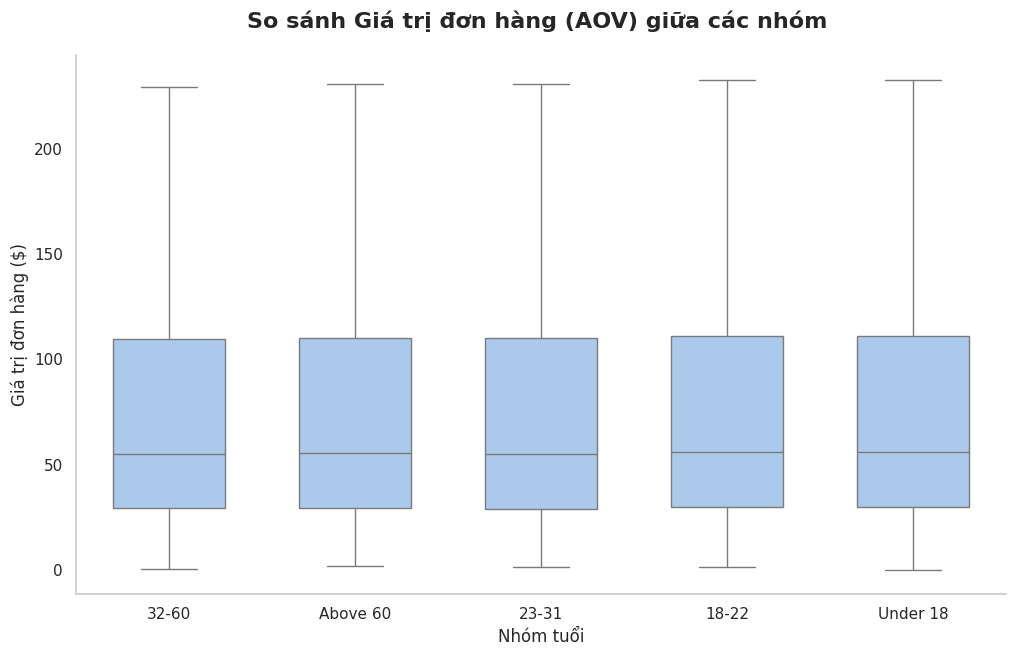

In [ ]:
sns.set(style="whitegrid", palette="pastel")

# Sắp xếp thứ tự các cột
order_list = ['32-60', 'Above 60', '23-31', '18-22', 'Under 18']

plt.figure(figsize=(12, 7))

# 1. Vẽ Boxplot: Cho thấy phân phối và giá trị trung vị
# showfliers=False để ẩn bớt các điểm ngoại lai quá xa
ax = sns.boxplot(data=order_spending, x='age_group', y='order_total',
                 order=order_list, showfliers=False, width=0.6)

#  so sánh '32-60' với tất cả các nhóm còn lại
pairs = [
    ("32-60", "Above 60"),
    ("32-60", "23-31"),
    ("32-60", "18-22"),
    ("32-60", "Under 18")
]

plt.title("So sánh Giá trị đơn hàng (AOV) giữa các nhóm ", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Nhóm tuổi", fontsize=12)
plt.ylabel("Giá trị đơn hàng ($)", fontsize=12)
plt.grid(False)

sns.despine()

plt.show()

### Biểu đồ cột ghép thống kế số đơn hàng người tiêu dùng theo độ tuổi

In [ ]:
users_agg = users.groupby('age_group')['id'].count().rename('Total Users')

# Tính Total Orders theo Age Group

merged_orders = pd.merge(order_items, users[['id', 'age_group']], left_on='user_id', right_on='id')
orders_agg = merged_orders.groupby('age_group')['order_id'].count().rename('Total Orders')

# Gộp 2 chỉ số lại thành 1 DataFrame chung
summary_df = pd.concat([orders_agg, users_agg], axis=1)

# Sắp xếp dữ liệu giảm dần theo Total Orders
summary_df = summary_df.sort_values(by='Total Orders', ascending=False)

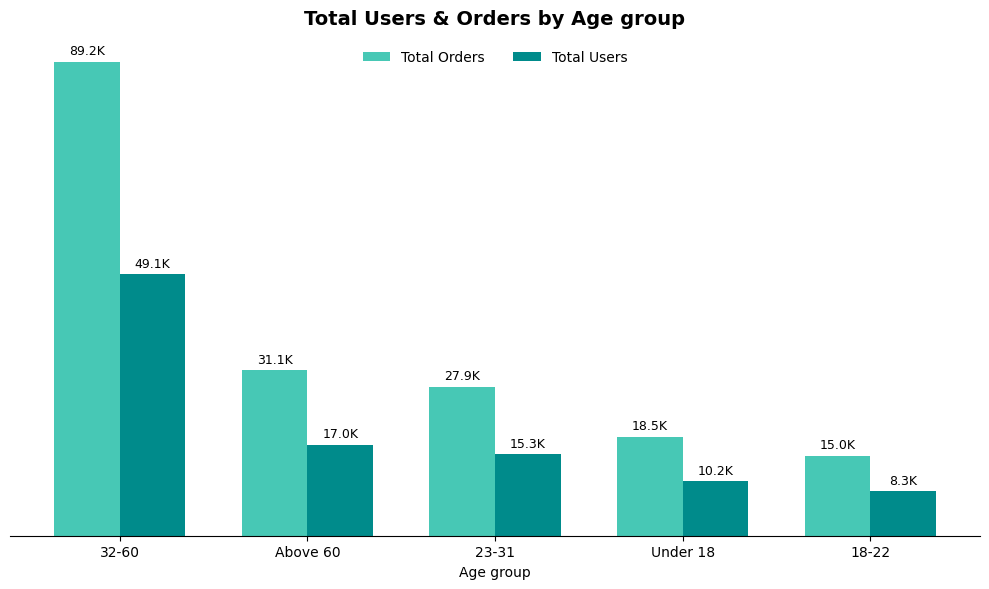

In [ ]:
plt.figure(figsize=(10, 6))

plt.style.use('default')
# Thiết lập vị trí cho các cột
x = np.arange(len(summary_df))  # Vị trí các nhóm trên trục X
width = 0.35                    # Độ rộng của mỗi cột

# Định nghĩa màu sắc
color_orders = '#47c8b5'
color_users = '#008b8b'

# Vẽ 2 cột song song
rects1 = plt.bar(x - width/2, summary_df['Total Orders'], width, label='Total Orders', color=color_orders)
rects2 = plt.bar(x + width/2, summary_df['Total Users'], width, label='Total Users', color=color_users)

def autolabel(rects):
    """Hàm gắn nhãn số liệu lên đầu cột"""
    for rect in rects:
        height = rect.get_height()
        plt.text(
            rect.get_x() + rect.get_width()/2.,
            height + (summary_df['Total Orders'].max() * 0.01),
            f'{height/1000:.1f}K',
            ha='center', va='bottom', fontsize=9
        )

autolabel(rects1)
autolabel(rects2)

plt.title('Total Users & Orders by Age group', fontsize=14, fontweight='bold', pad=10)

plt.xlabel('Age group')
plt.xticks(x, summary_df.index)
plt.legend(frameon=False, loc='upper center', ncol=2)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.yticks([]) # Ẩn trục số Y

plt.tight_layout()
plt.show()

**Sự chênh lệch giữa số lượng chi tiêu các nhóm có thể được giải thích như sau:**    
Mặc dù AOV giữa các độ tuổi không có sự khác biệt nhưng lại có sự chênh lệch lớn về tổng chi tiêu theo từng nhóm tuôi thì lý do đến từ sự khác biệt về số lượng ==> Nhóm nào có tổng lượng khách hàng càng lớn ==> số lượng đơn hàng tạo ra càng lớn ==> doanh thu càng lớn.  

Qua phân tích theo độ tuổi có thể thấy rằng tệp khách hàng từ 32-60, 60+ sẽ là 2 tệp khách hàng chính nhất của doanh nghiệp

# Mô hình RFM

In [ ]:
df_merged = orders.merge(order_items, on='order_id', how='left')
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181702 entries, 0 to 181701
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_id           181702 non-null  int64         
 1   user_id_x          181702 non-null  int64         
 2   status_x           181702 non-null  object        
 3   gender             181702 non-null  object        
 4   created_at_x       181702 non-null  datetime64[ns]
 5   returned_at_x      18205 non-null   object        
 6   shipped_at_x       118013 non-null  object        
 7   delivered_at_x     63607 non-null   object        
 8   num_of_item        181702 non-null  int64         
 9   year               181702 non-null  int32         
 10  quarter            181702 non-null  int32         
 11  id                 181702 non-null  int64         
 12  user_id_y          181702 non-null  int64         
 13  product_id         181702 non-null  int64   

In [ ]:
ranking_RFM = pd.read_csv(r'/content/drive/MyDrive/DS111/ranking_RFM.csv')
# --- 1: Tính chỉ số R - F - M

# Join Orders với Order Items để lấy doanh thu
df_merged = orders.merge(order_items, on='order_id', how='left')

# Group by User_ID để tính metrics
customer_stats = df_merged.groupby('user_id_x').agg({
    'created_at_x': 'max',            # Lấy ngày mua gần nhất (Recency)
    'order_id': 'nunique',            # Đếm số đơn hàng (Frequency)
    'sale_price': 'sum'               # Tổng tiền (Monetary)
}).reset_index()

customer_stats.columns = ['user_id', 'latest_purchase_date', 'Frequency', 'Monetary']
customer_stats['latest_purchase_date'] = pd.to_datetime(customer_stats['latest_purchase_date'])

# Tính Recency
global_max_date = customer_stats['latest_purchase_date'].max()
customer_stats['Recency'] = (global_max_date - customer_stats['latest_purchase_date']).dt.days

# --- 2: Tính điểm dựa trên Percentile


# Tính phần trăm thứ hạng (rank pct)
# Recency: Số ngày càng lớn -> rank càng nhỏ
customer_stats['Recency_pct'] = customer_stats['Recency'].rank(pct=True, ascending=False)

# Frequency & Monetary: Càng to càng tốt
customer_stats['Frequency_pct'] = customer_stats['Frequency'].rank(pct=True, ascending=True)
customer_stats['Monetary_pct'] = customer_stats['Monetary'].rank(pct=True, ascending=True)

# Hàm để quy đổi Percentile sang Score (1-5)
def get_score(pct):
    if pct <= 0.2: return 1
    elif pct <= 0.4: return 2
    elif pct <= 0.6: return 3
    elif pct <= 0.8: return 4
    else: return 5

# Áp dụng hàm tính điểm
customer_stats['R_Score'] = customer_stats['Recency_pct'].apply(get_score).astype(str)
customer_stats['F_Score'] = customer_stats['Frequency_pct'].apply(get_score).astype(str)
customer_stats['M_Score'] = customer_stats['Monetary_pct'].apply(get_score).astype(str)

# Tạo cột RFM Score tổng hợp (ví dụ: "555")
customer_stats['RFM_Score'] = customer_stats['R_Score'] + customer_stats['F_Score'] + customer_stats['M_Score']

# ---  3: Ánh xạ qua bảng segment (Tương ứng Customer_Segment_RFM) ---

# Chuyển Scores sang string
ranking_RFM['Scores'] = ranking_RFM['Scores'].astype(str)

# Merge để lấy tên Segment
final_df = customer_stats.merge(ranking_RFM, left_on='RFM_Score', right_on='Scores', how='left')

# Xử lý nếu có Segment bị NaN
final_df['Segment'] = final_df['Segment'].fillna('Other')

In [ ]:
summary_table = final_df.groupby('Segment').agg({
    'user_id': 'count',          # Đếm số khách hàng
    'Frequency': 'sum',          # Tổng số đơn hàng (Total Orders)
    'Monetary': 'sum'            # Tổng doanh thu (Total Revenue)
}).reset_index()

# Đổi tên cột hiển thị
summary_table.columns = ['Segment', 'Total Customers', 'Total Orders', 'Total Revenue']

# AOV = Total Revenue / Total Orders
summary_table['AOV'] = summary_table['Total Revenue'] / summary_table['Total Orders']

summary_table['Total Revenue'] = summary_table['Total Revenue'].round(2)
summary_table['AOV'] = summary_table['AOV'].round(2)

# Sắp xếp
summary_table = summary_table.sort_values(by='Total Revenue', ascending=False)

display(summary_table)

,Segment,Total Customers,Total Orders,Total Revenue,AOV
3,Champions,9434,27521,2853157.87,103.67
1,At Risk,12357,21381,2585314.99,120.92
6,Loyal,6956,16875,1543071.81,91.44
10,Promising,10042,10042,1115576.72,111.09
4,Hibernating customers,13356,13356,850478.57,63.68
7,Need Attention,4497,6818,694012.22,101.79
9,Potential Loyalist,6689,10638,510099.85,47.95
2,Cannot Lose Them,1194,3006,260814.49,86.76
8,New Customers,4914,4914,166096.23,33.80
0,About To Sleep,6418,6516,138051.17,21.19
